In [1]:
import sys
sys.path.insert(0, "src")
from profiles import *
from collections.abc import Callable
from matplotlib.colors import ListedColormap
from operator import attrgetter
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
with open("artifacts/profiles.json") as file:
    profiles = [Profile.model_validate(profile_json) for profile_json in json.load(file)]

len(profiles)

26353

In [3]:
def is_ev(trip: Trip) -> bool:
    return trip.vehicle is not None and trip.vehicle.fuel_type in {"Electric", "Plug-in Hybrid"}

Text(0.5, 0.98, 'Trip count per OD pair')

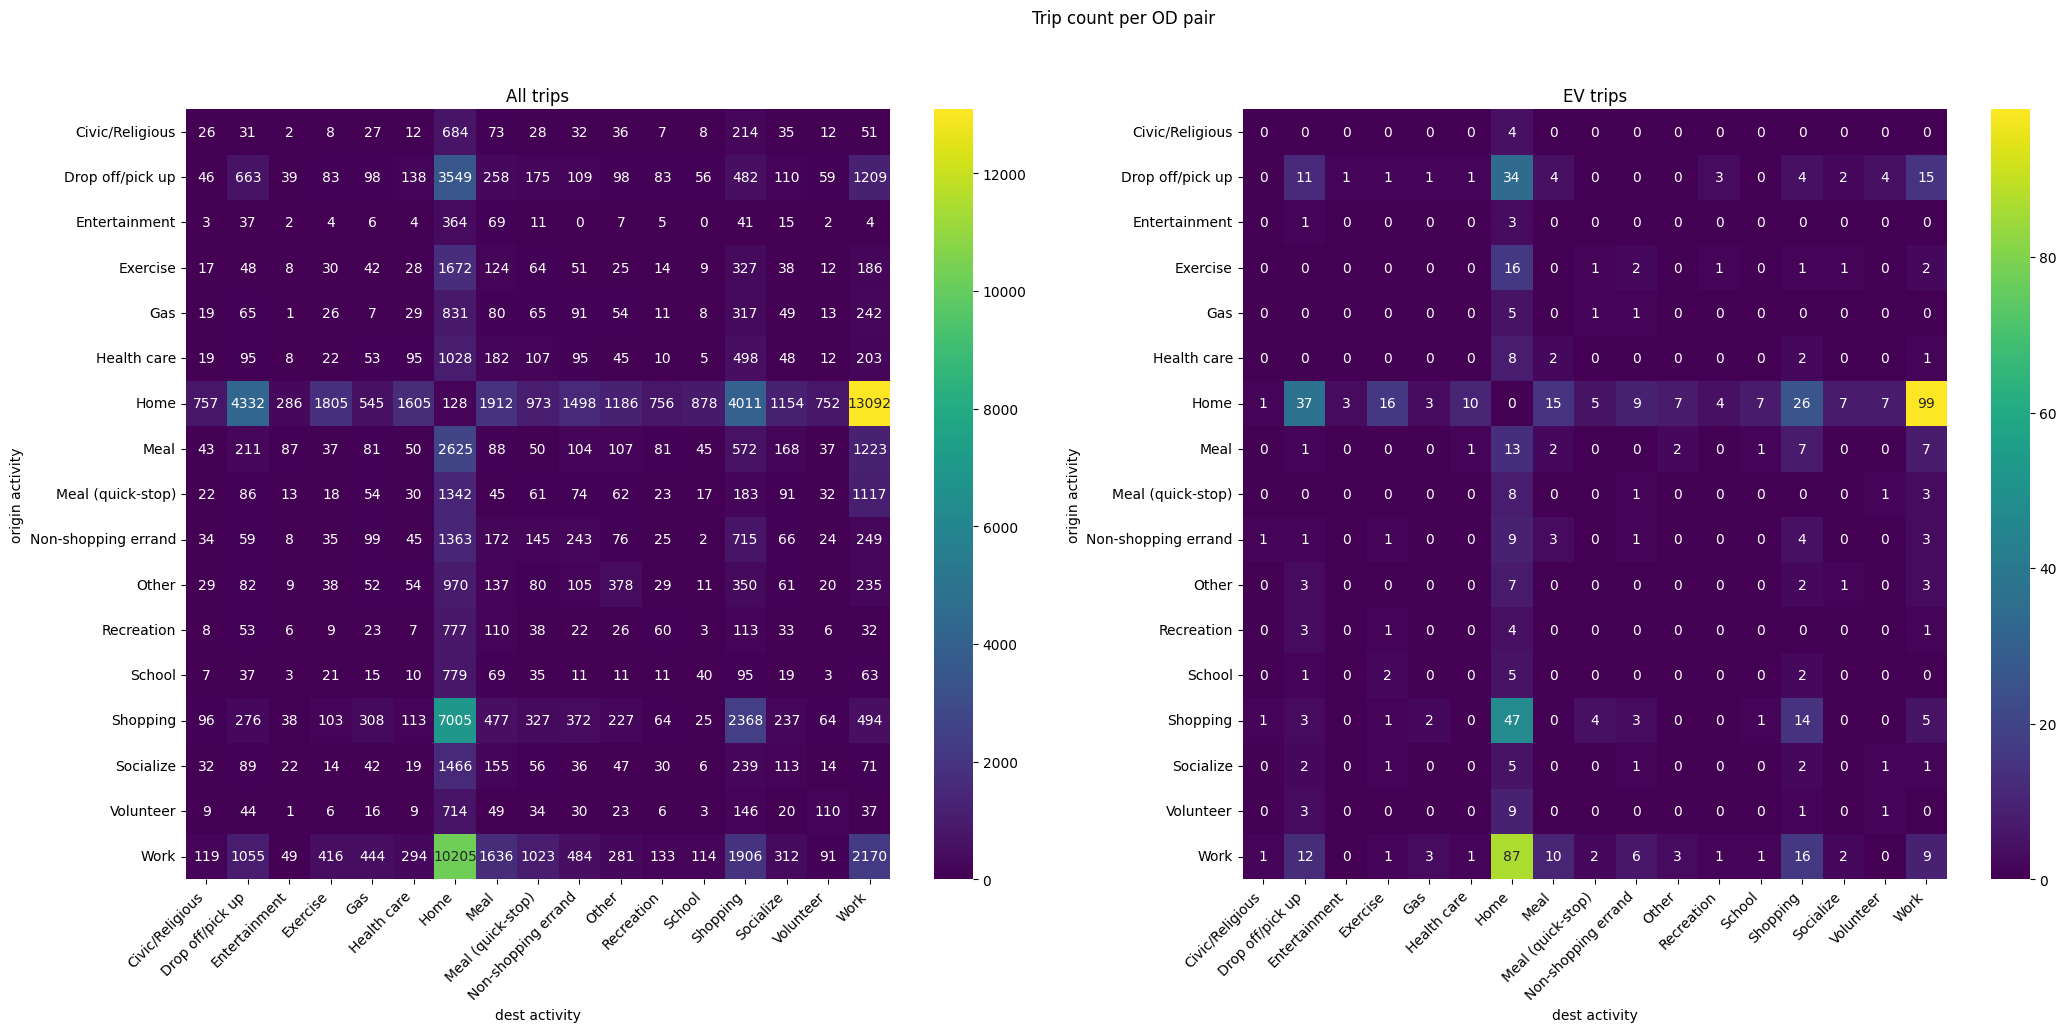

In [4]:

od_rows: list[dict] = [
    {
        "origin_activity": trip.origin_activity,
        "dest_activity": trip.dest_activity,
        "is_ev": is_ev(trip),
    }
    for profile in profiles
    for trip in profile.trips
]
od_df = pd.DataFrame(od_rows)

def count_matrix(frame: pd.DataFrame) -> pd.DataFrame:
    return (
        frame.groupby(["origin_activity", "dest_activity"])
        .size()
        .unstack("dest_activity", fill_value = 0)
    )

matrix_all = count_matrix(od_df)
matrix_ev = count_matrix(od_df[od_df["is_ev"]])

fig, (left_ax, right_ax) = plt.subplots(1, 2, figsize = (25, 10))
for matrix, axis, title in [(matrix_all, left_ax, "All trips"), (matrix_ev, right_ax, "EV trips")]:
    sns.heatmap(matrix, annot = True, fmt = "d", cmap = "viridis", ax = axis)
    axis.set_xticklabels(axis.get_xticklabels(), rotation = 45, ha = "right")
    axis.set_title(title)
    axis.set_xlabel("dest activity")
    axis.set_ylabel("origin activity")
fig.suptitle("Trip count per OD pair")

Text(0.5, 0.98, 'Mean trip distance per OD pair')

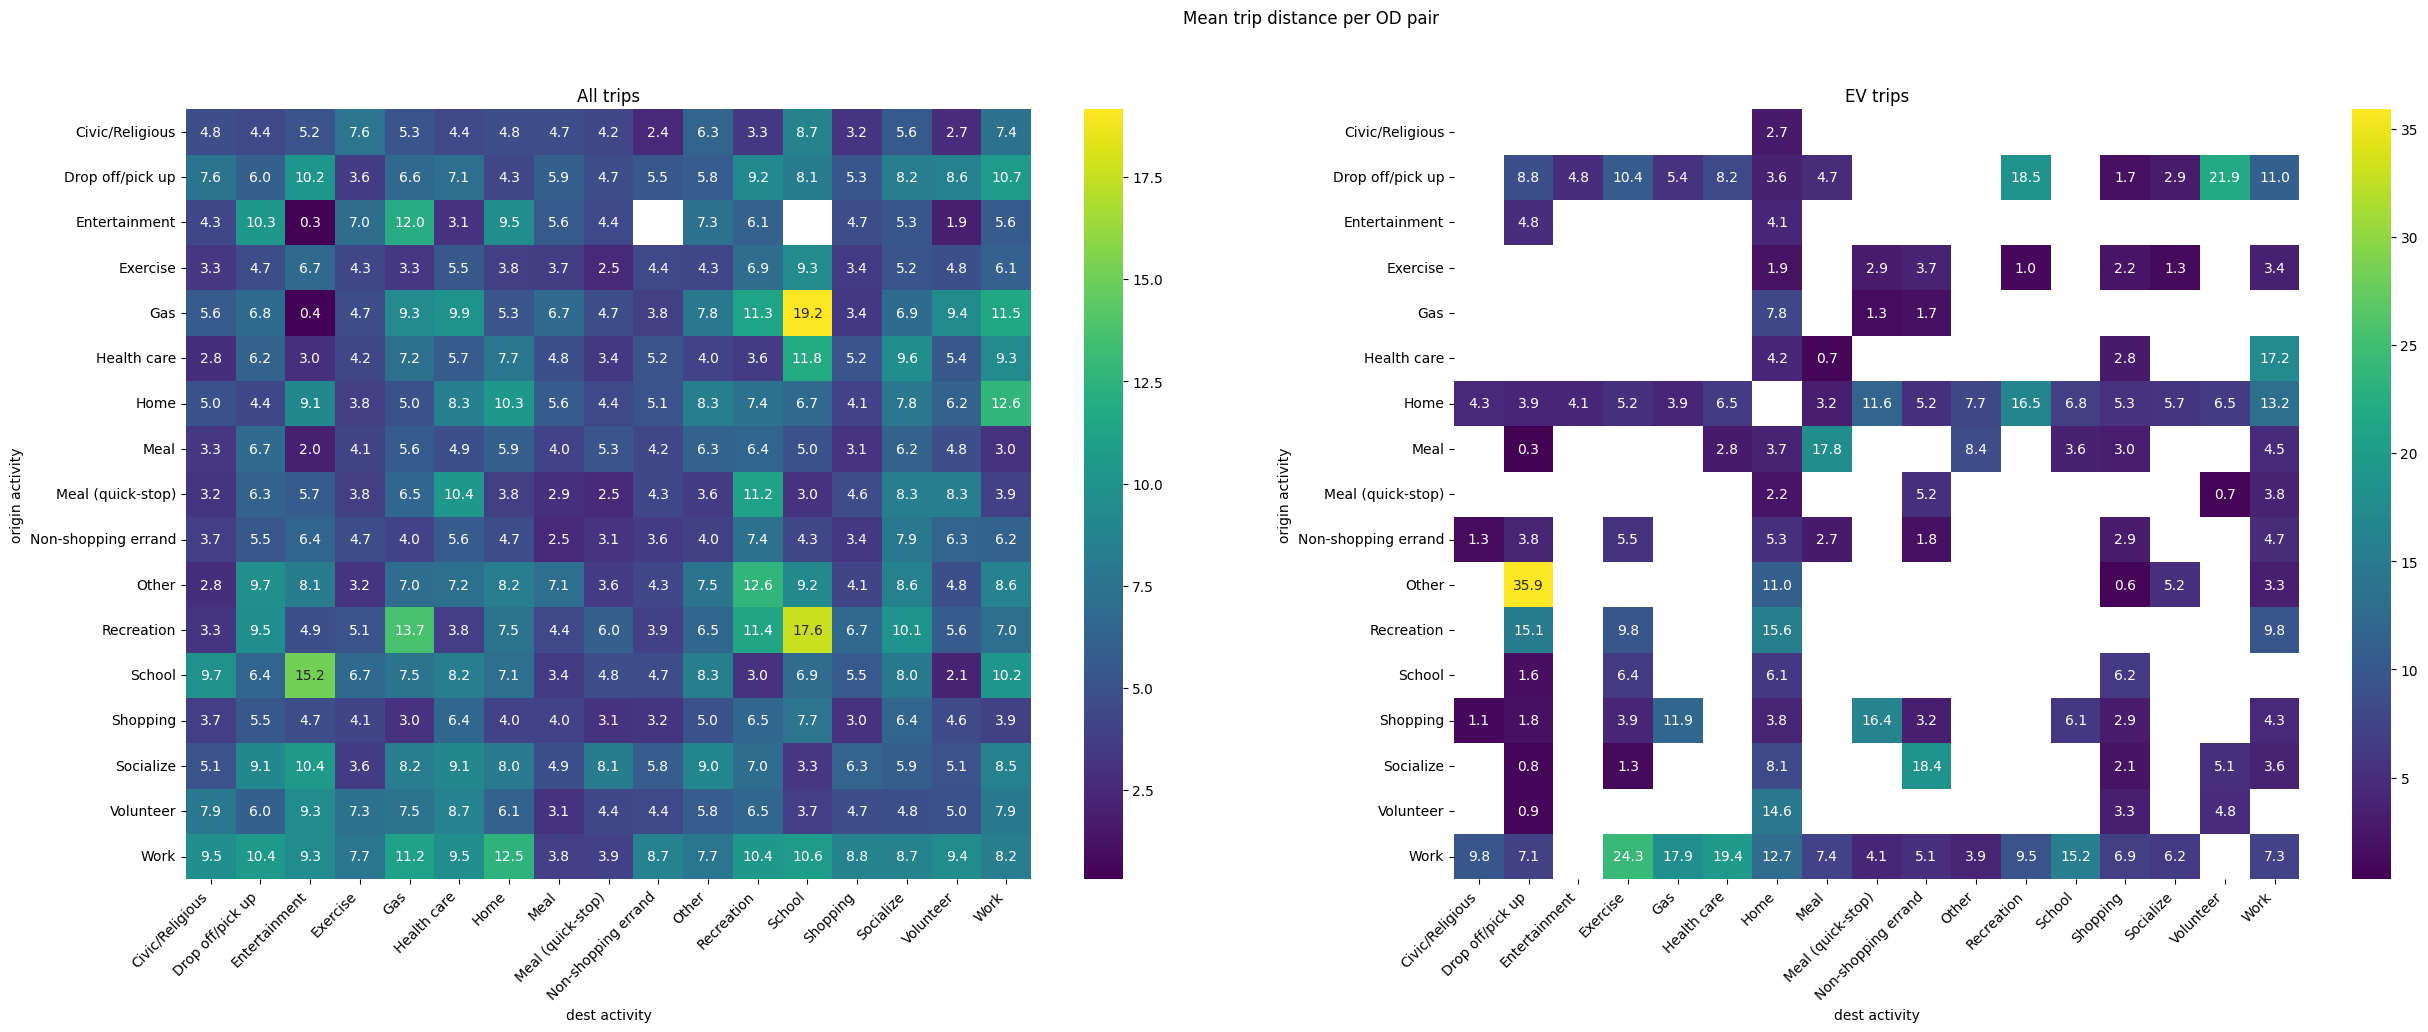

In [5]:
distance_rows: list[dict] = [
    {
        "origin_activity": trip.origin_activity,
        "dest_activity": trip.dest_activity,
        "distance": trip.distance,
        "is_ev": is_ev(trip),
    }
    for profile in profiles
    for trip in profile.trips
]
distance_df = pd.DataFrame(distance_rows)
distance_cap = distance_df["distance"].quantile(0.99)
distance_df = distance_df[distance_df["distance"] <= distance_cap]

def distance_matrix(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.pivot_table(
        index = "origin_activity",
        columns = "dest_activity",
        values = "distance",
        aggfunc = "mean",
    )

matrix_all = distance_matrix(distance_df)
matrix_ev = distance_matrix(distance_df[distance_df["is_ev"]])

def format_distance(value: float) -> str:
    if pd.isna(value):
        return ""
    return f"{value:.1f}"

fig, (left_ax, right_ax) = plt.subplots(1, 2, figsize = (30, 10))
for matrix, axis, title in [(matrix_all, left_ax, "All trips"), (matrix_ev, right_ax, "EV trips")]:
    sns.heatmap(
        matrix,
        annot = matrix.map(format_distance),
        fmt = "",
        cmap = "viridis",
        ax = axis,
    )
    axis.set_xticklabels(axis.get_xticklabels(), rotation = 45, ha = "right")
    axis.set_title(title)
    axis.set_xlabel("dest activity")
    axis.set_ylabel("origin activity")
fig.suptitle("Mean trip distance per OD pair")

Text(0.5, 0.98, 'Mean household income per OD pair')

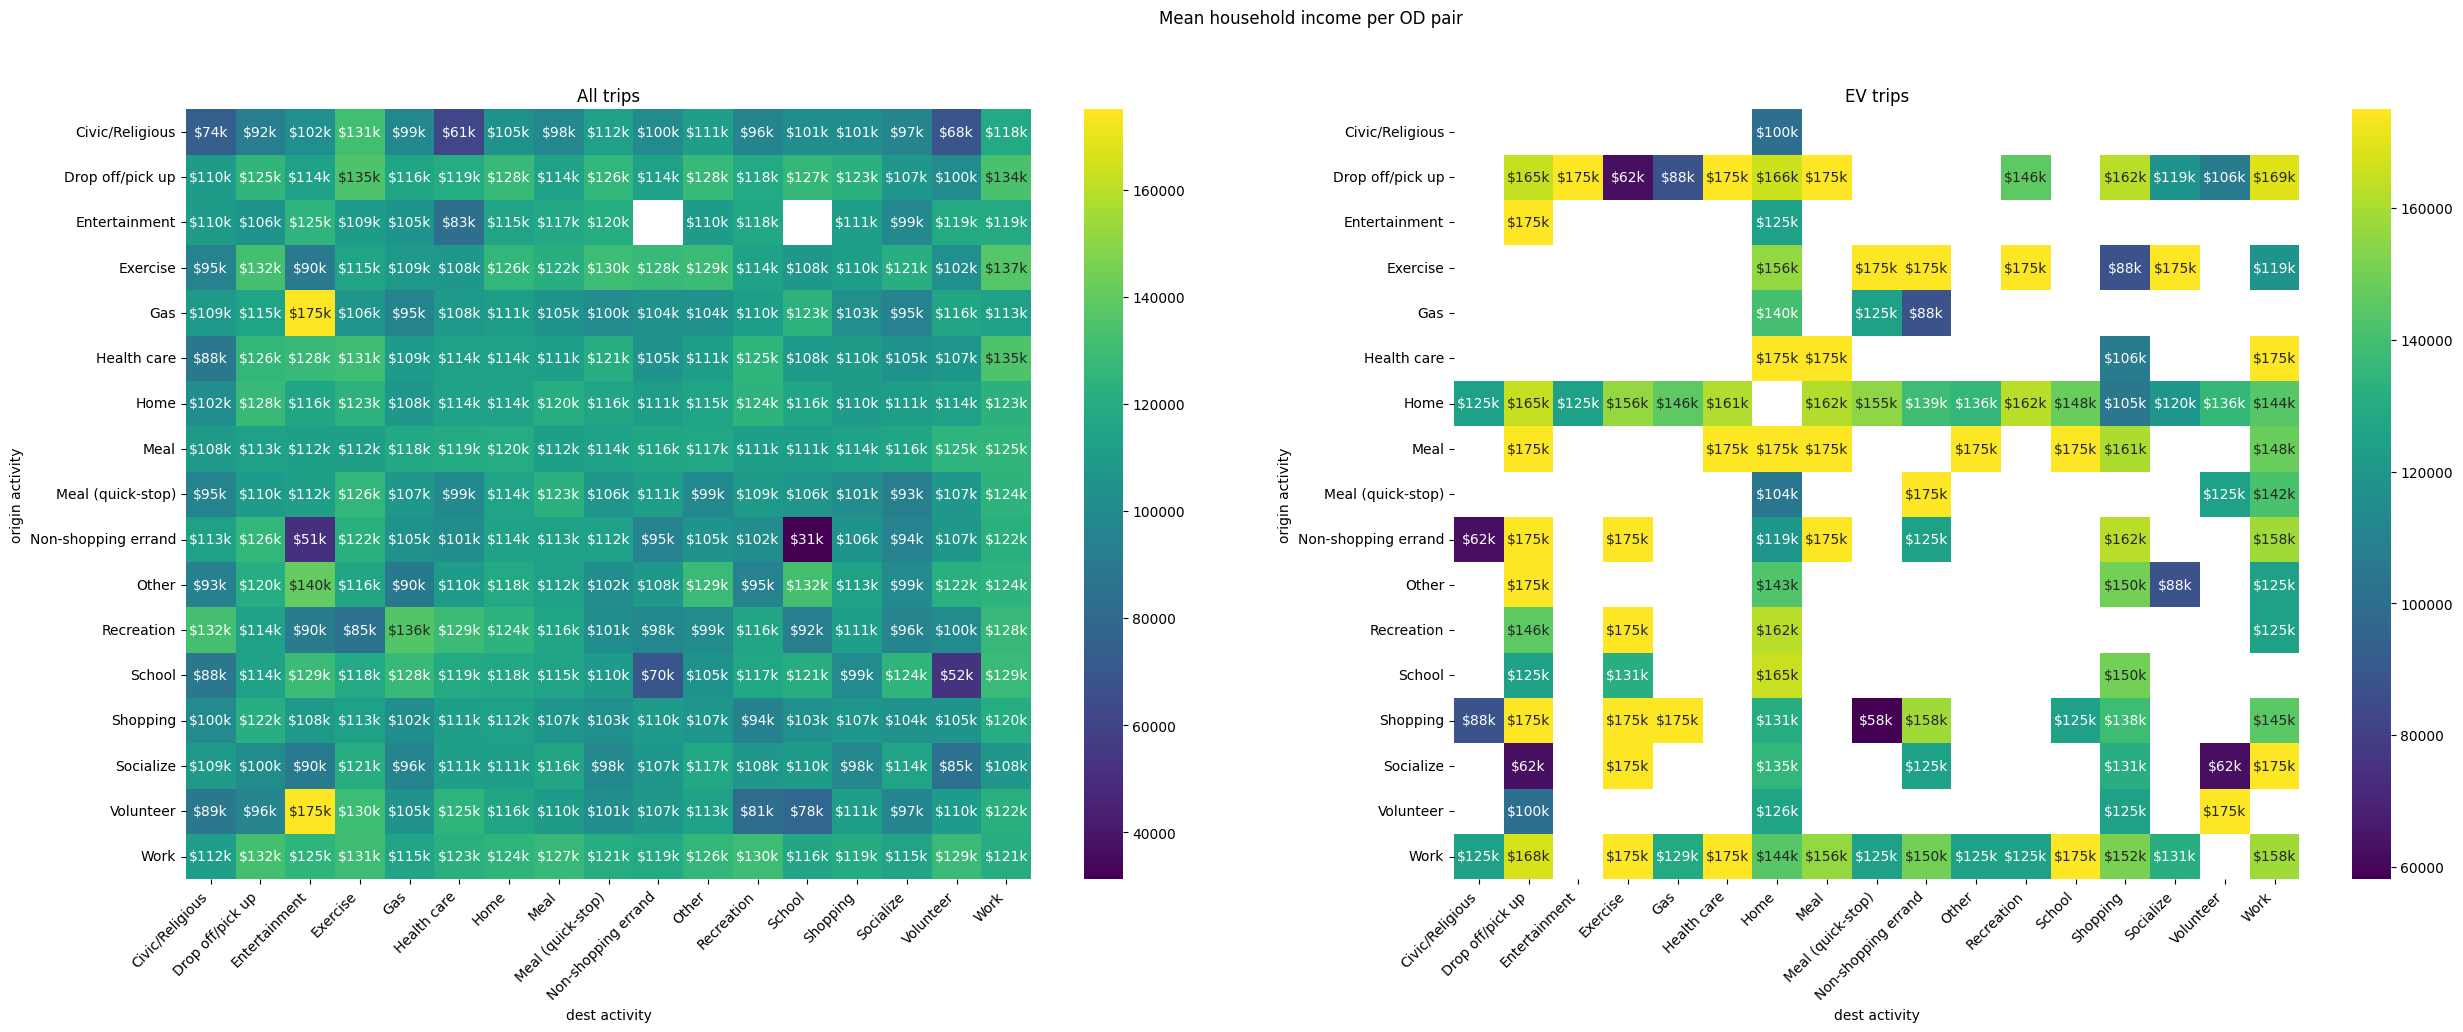

In [6]:
INCOME_MIDPOINTS: dict[str, float] = {
    "Less than $15,000": 7_500,
    "$15,000 - $24,999": 20_000,
    "$25,000 - 34,999": 30_000,
    "$35,000 - 49,999": 42_500,
    "$50,000 - $74,999": 62_500,
    "$75,000 - $99,999": 87_500,
    "$100,000 - $149,999": 125_000,
    "$150,000 or more": 175_000,
}

trip_rows: list[dict] = [
    {
        "origin_activity": trip.origin_activity,
        "dest_activity": trip.dest_activity,
        "income": INCOME_MIDPOINTS[profile.household_income],
        "is_ev": is_ev(trip),
    }
    for profile in profiles
    for trip in profile.trips
]
trips_df = pd.DataFrame(trip_rows)

def income_matrix(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.pivot_table(
        index = "origin_activity",
        columns = "dest_activity",
        values = "income",
        aggfunc = "mean",
    )

matrix_all = income_matrix(trips_df)
matrix_ev = income_matrix(trips_df[trips_df["is_ev"]])

def format_income(value: float) -> str:
    if pd.isna(value):
        return ""
    return f"${value/1000:.0f}k"

fig, (left_ax, right_ax) = plt.subplots(1, 2, figsize = (30, 10))
for matrix, axis, title in [(matrix_all, left_ax, "All trips"), (matrix_ev, right_ax, "EV trips")]:
    sns.heatmap(
        matrix,
        annot = matrix.map(format_income),
        fmt = "",
        cmap = "viridis",
        ax = axis,
    )
    axis.set_xticklabels(axis.get_xticklabels(), rotation = 45, ha = "right")
    axis.set_title(title)
    axis.set_xlabel("dest activity")
    axis.set_ylabel("origin activity")
fig.suptitle("Mean household income per OD pair")

Text(0.5, 0.98, 'Mean age per OD pair')

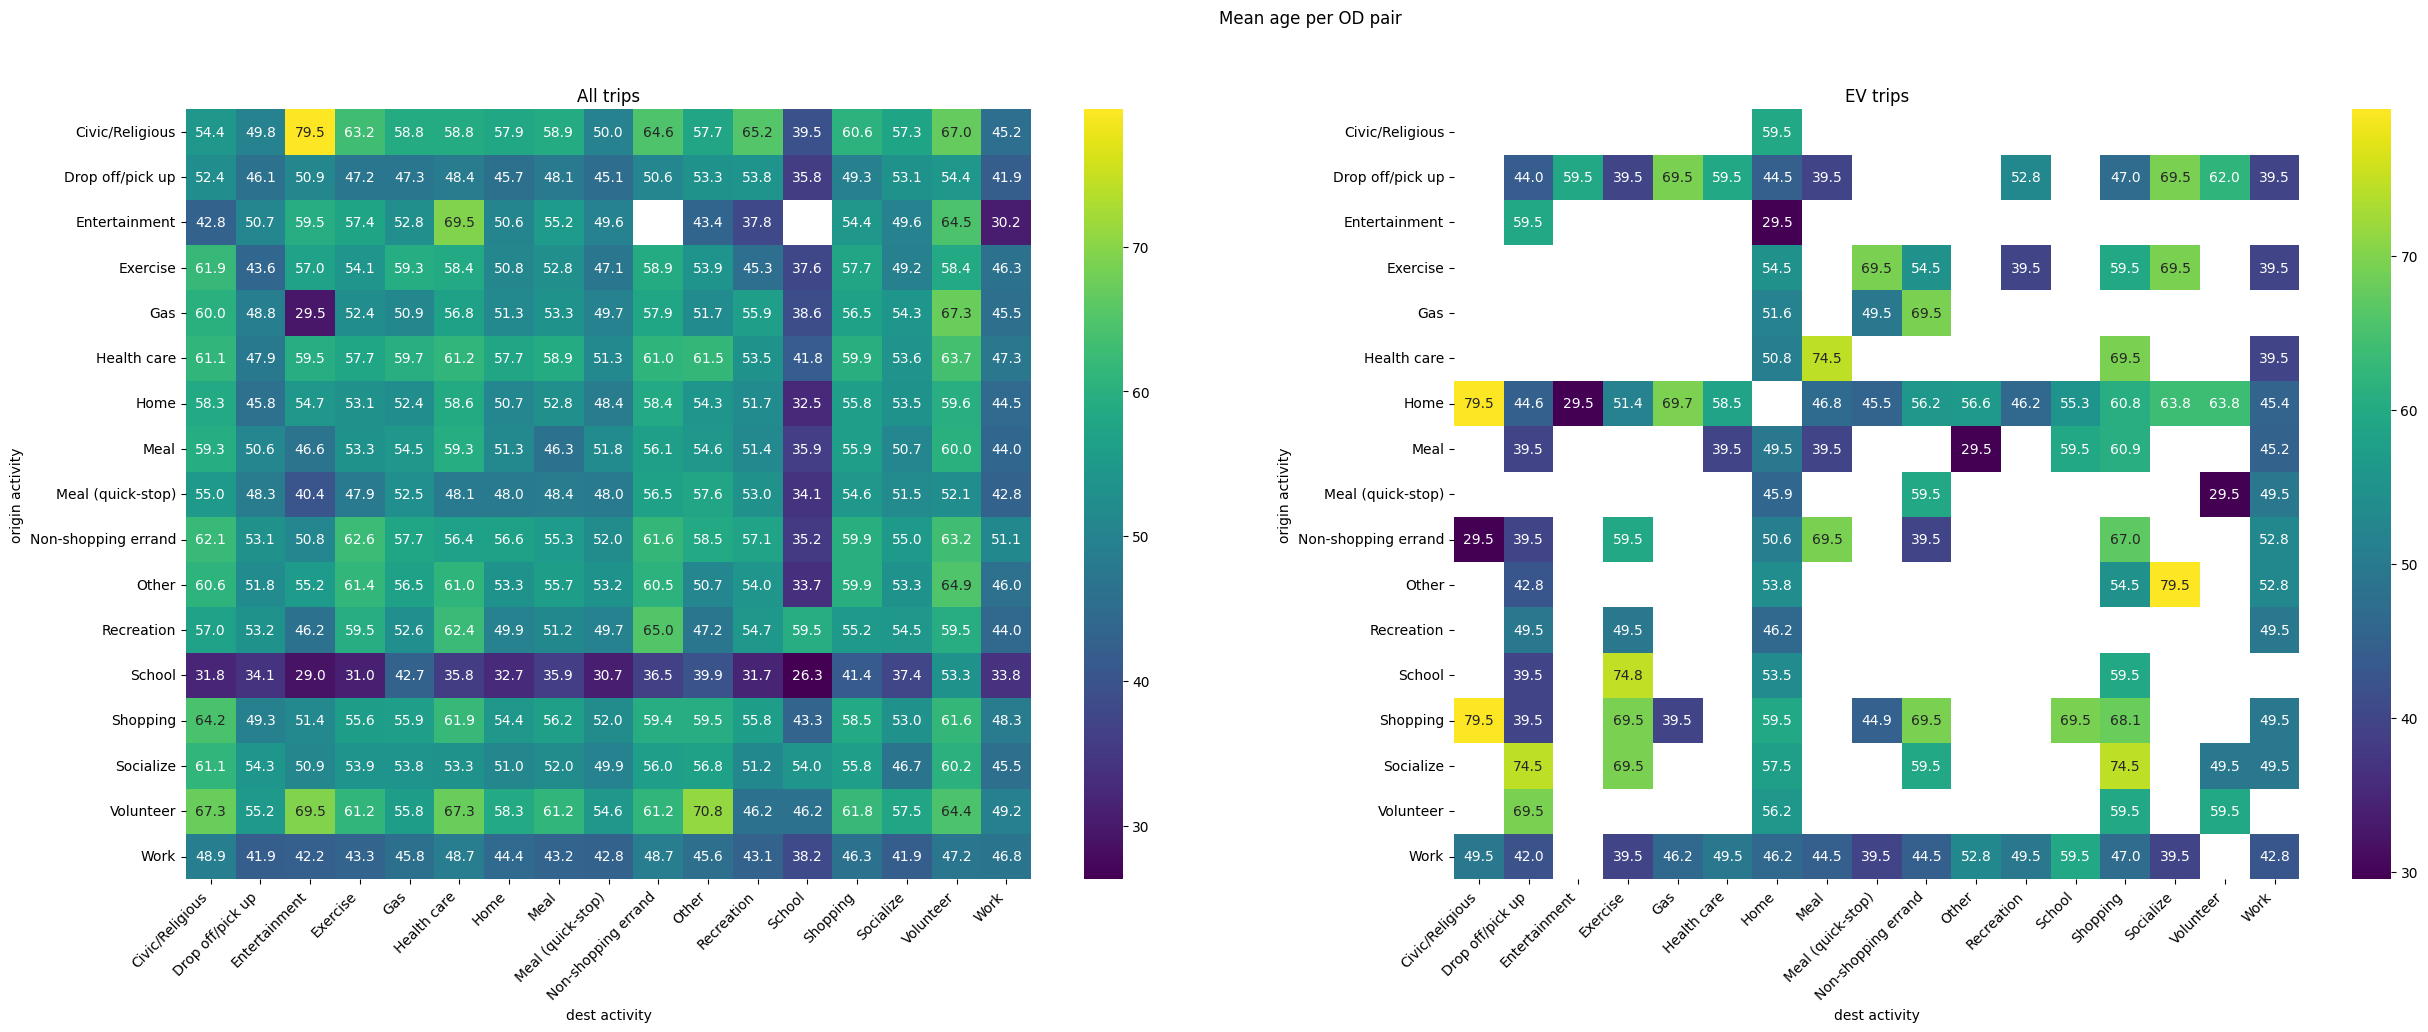

In [7]:
AGE_MIDPOINTS: dict[str, float] = {
    "Under 5 years old": 2.5,
    "5 - 11 years": 8,
    "12 - 13 years": 12.5,
    "14 - 15 years": 14.5,
    "16 - 17 years": 16.5,
    "18 - 24 years": 21,
    "25 - 34 years": 29.5,
    "35 - 44 years": 39.5,
    "45 - 54 years": 49.5,
    "55 - 64 years": 59.5,
    "65 - 74 years": 69.5,
    "75 - 84 years": 79.5,
    "85 years or older": 90,
}

age_rows: list[dict] = [
    {
        "origin_activity": trip.origin_activity,
        "dest_activity": trip.dest_activity,
        "age": AGE_MIDPOINTS[profile.age_group],
        "is_ev": is_ev(trip),
    }
    for profile in profiles
    for trip in profile.trips
]
age_df = pd.DataFrame(age_rows)

def age_matrix(frame: pd.DataFrame) -> pd.DataFrame:
    return frame.pivot_table(
        index = "origin_activity",
        columns = "dest_activity",
        values = "age",
        aggfunc = "mean",
    )

matrix_all = age_matrix(age_df)
matrix_ev = age_matrix(age_df[age_df["is_ev"]])

def format_age(value: float) -> str:
    if pd.isna(value):
        return ""
    return f"{value:.1f}"

fig, (left_ax, right_ax) = plt.subplots(1, 2, figsize = (30, 10))
for matrix, axis, title in [(matrix_all, left_ax, "All trips"), (matrix_ev, right_ax, "EV trips")]:
    sns.heatmap(
        matrix,
        annot = matrix.map(format_age),
        fmt = "",
        cmap = "viridis",
        ax = axis,
    )
    axis.set_xticklabels(axis.get_xticklabels(), rotation = 45, ha = "right")
    axis.set_title(title)
    axis.set_xlabel("dest activity")
    axis.set_ylabel("origin activity")
fig.suptitle("Mean age per OD pair")

In [8]:
def mode_od_heatmap(
    profiles: list[Profile],
    extractor: Callable[[Profile], str | None],
    label_order: list[str],
    mode_priority: list[str],
    title: str,
    palette: str | None = None
) -> None:
    priority_rank: dict[str, int] = {label: index for index, label in enumerate(mode_priority)}

    trip_rows: list[dict] = [
        {
            "origin_activity": trip.origin_activity,
            "dest_activity": trip.dest_activity,
            "value": extractor(profile),
            "is_ev": is_ev(trip),
        }
        for profile in profiles
        for trip in profile.trips
        if extractor(profile) is not None
    ]
    od_df = pd.DataFrame(trip_rows)

    def pick_mode(series: pd.Series) -> str:
        modes = series.mode()
        if len(modes) == 1:
            return modes.iloc[0]
        return min(modes, key = priority_rank.__getitem__)

    def code_matrix(frame: pd.DataFrame) -> pd.DataFrame:
        mode_series = (
            frame.groupby(["origin_activity", "dest_activity"])["value"]
            .agg(pick_mode)
        )
        return pd.Series(
            pd.Categorical(mode_series, categories = label_order).codes,
            index = mode_series.index,
        ).unstack("dest_activity")

    matrix_all = code_matrix(od_df)
    matrix_ev = code_matrix(od_df[od_df["is_ev"]])

    palette = sns.color_palette(palette if palette else "Set2", n_colors = len(label_order))
    cmap = ListedColormap(palette)

    fig, (left_ax, right_ax) = plt.subplots(1, 2, figsize = (30, 10))
    for matrix, axis, subtitle in [(matrix_all, left_ax, "All trips"), (matrix_ev, right_ax, "EV trips")]:
        sns.heatmap(
            matrix,
            cmap = cmap,
            vmin = -0.5,
            vmax = len(label_order) - 0.5,
            cbar_kws = {"ticks": list(range(len(label_order)))},
            ax = axis,
        )
        colorbar = axis.collections[0].colorbar
        colorbar.set_ticklabels(label_order)
        axis.set_xticklabels(axis.get_xticklabels(), rotation = 45, ha = "right")
        axis.set_title(subtitle)
        axis.set_xlabel("dest activity")
        axis.set_ylabel("origin activity")
    fig.suptitle(title)


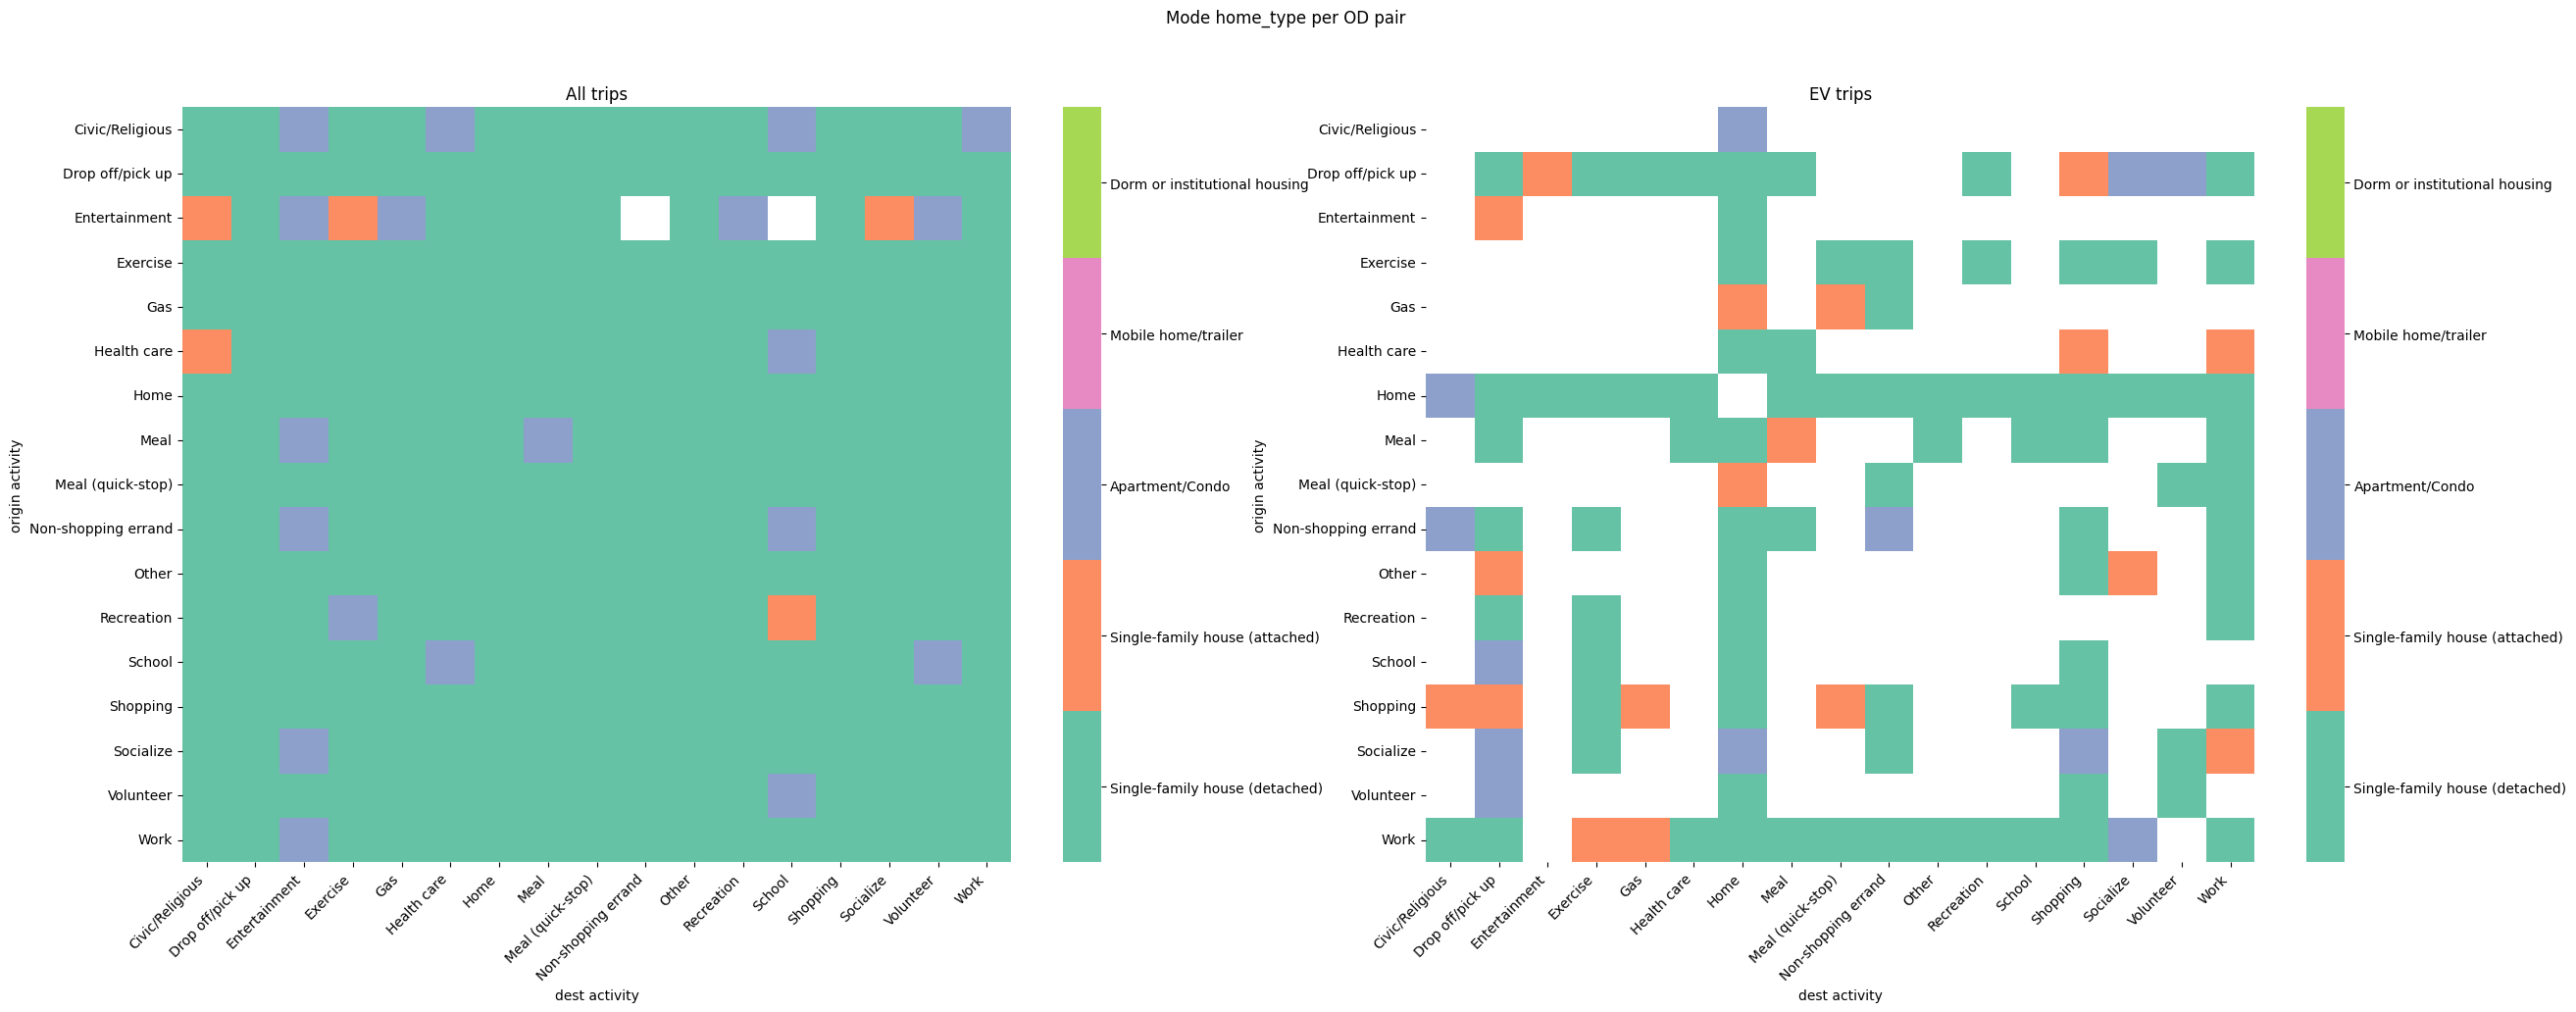

In [9]:
mode_od_heatmap(
    profiles,
    extractor = attrgetter("home_type"),
    label_order = [label for label in HOME_TYPE_LABELS.values() if label is not None],
    mode_priority = [
        "Mobile home/trailer",
        "Dorm or institutional housing",
        "Apartment/Condo",
        "Single-family house (attached)",
        "Single-family house (detached)",
    ],
    title = "Mode home_type per OD pair",
)

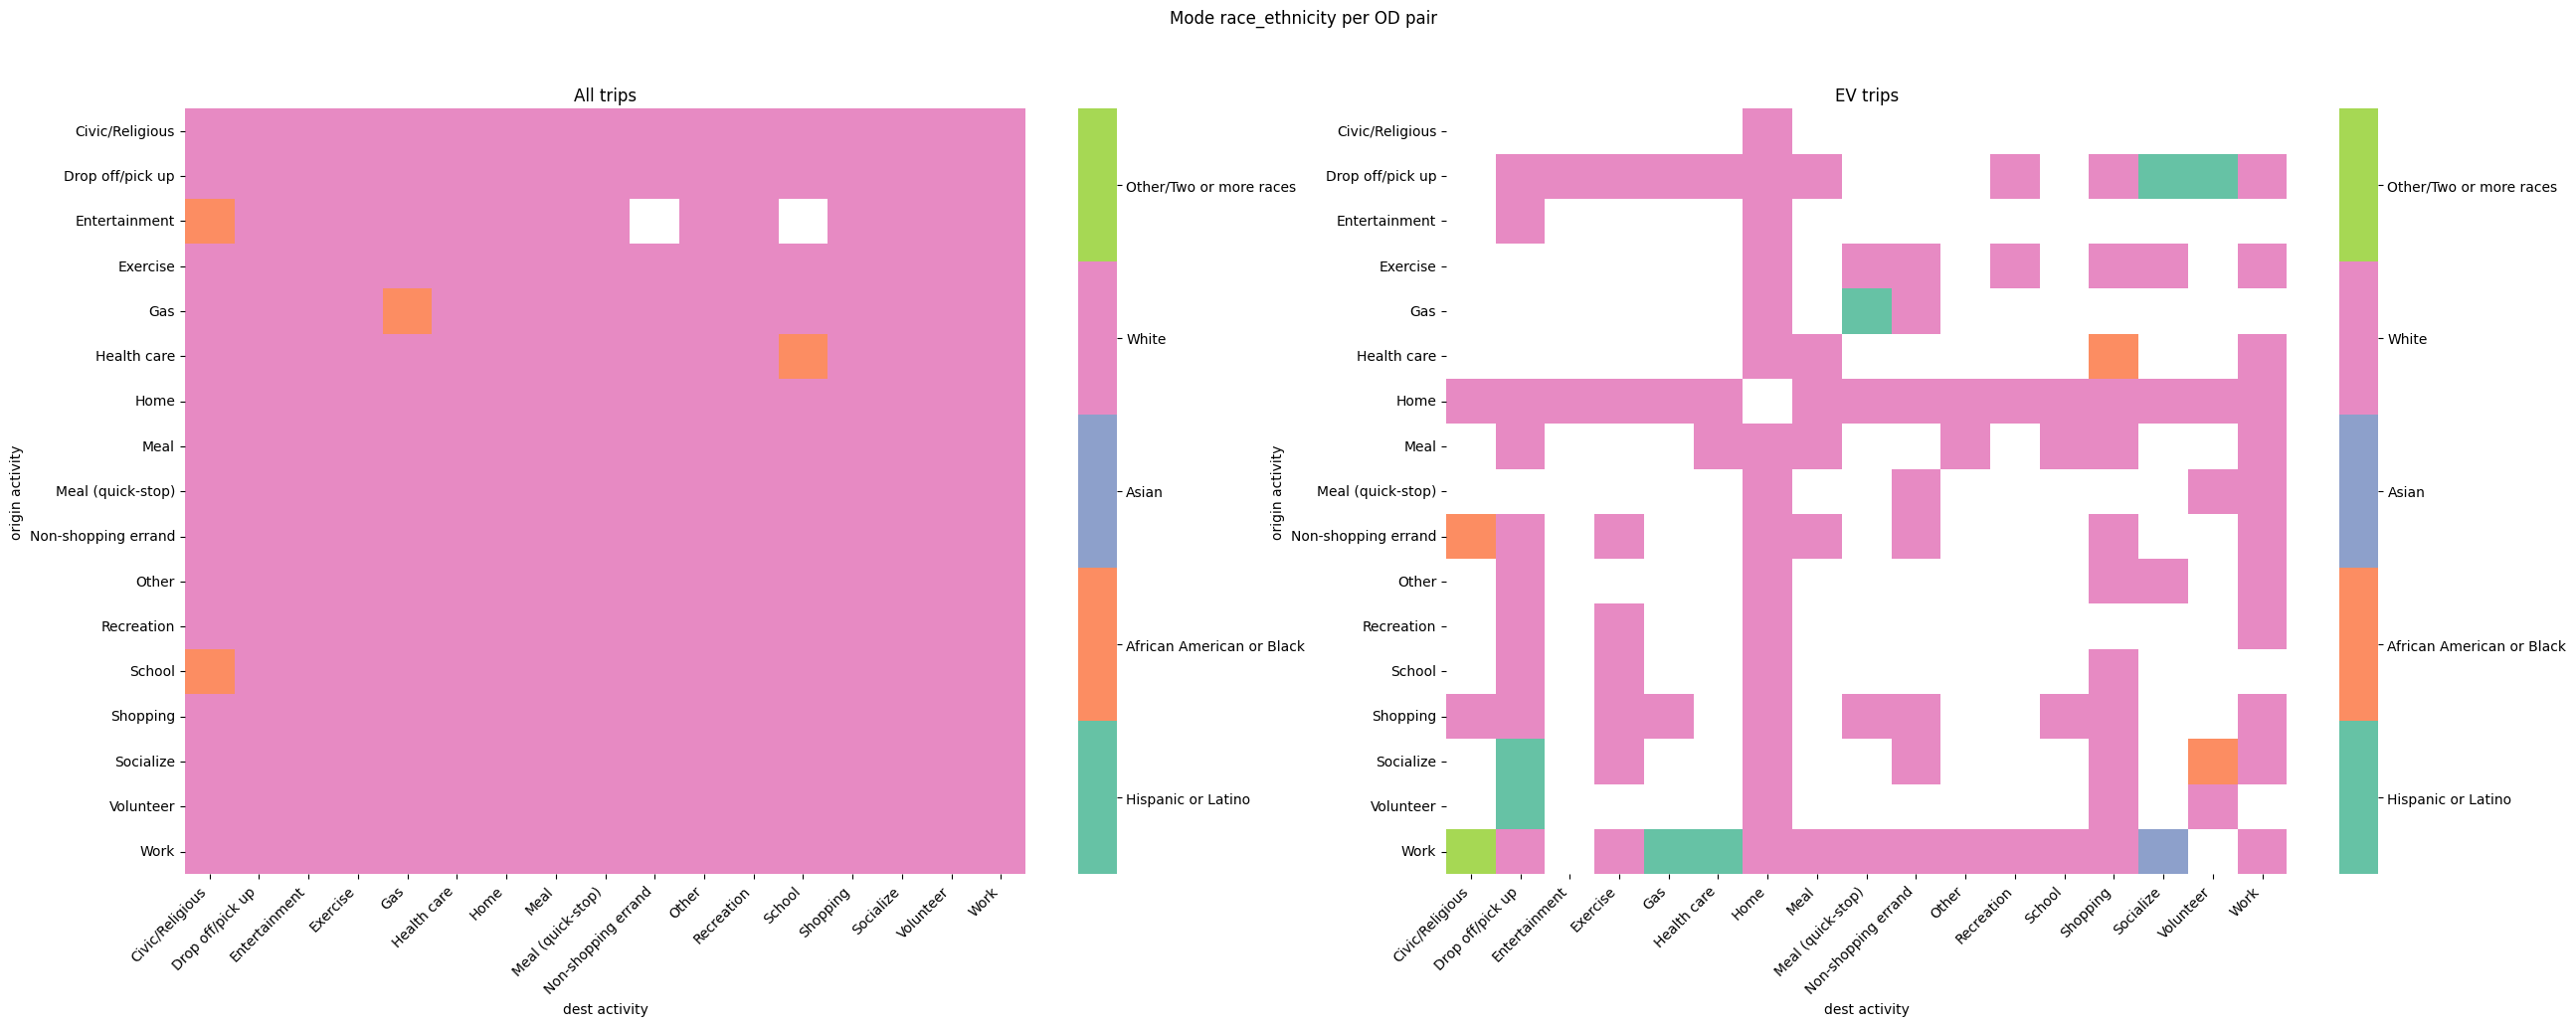

In [10]:
mode_od_heatmap(
    profiles,
    extractor = attrgetter("race_ethnicity"),
    label_order = [label for label in RACEETHNICITY_LABELS.values() if label is not None],
    mode_priority = [
        "Hispanic or Latino",
        "African American or Black",
        "Asian",
        "Other/Two or more races",
        "White",
    ],
    title = "Mode race_ethnicity per OD pair",
)

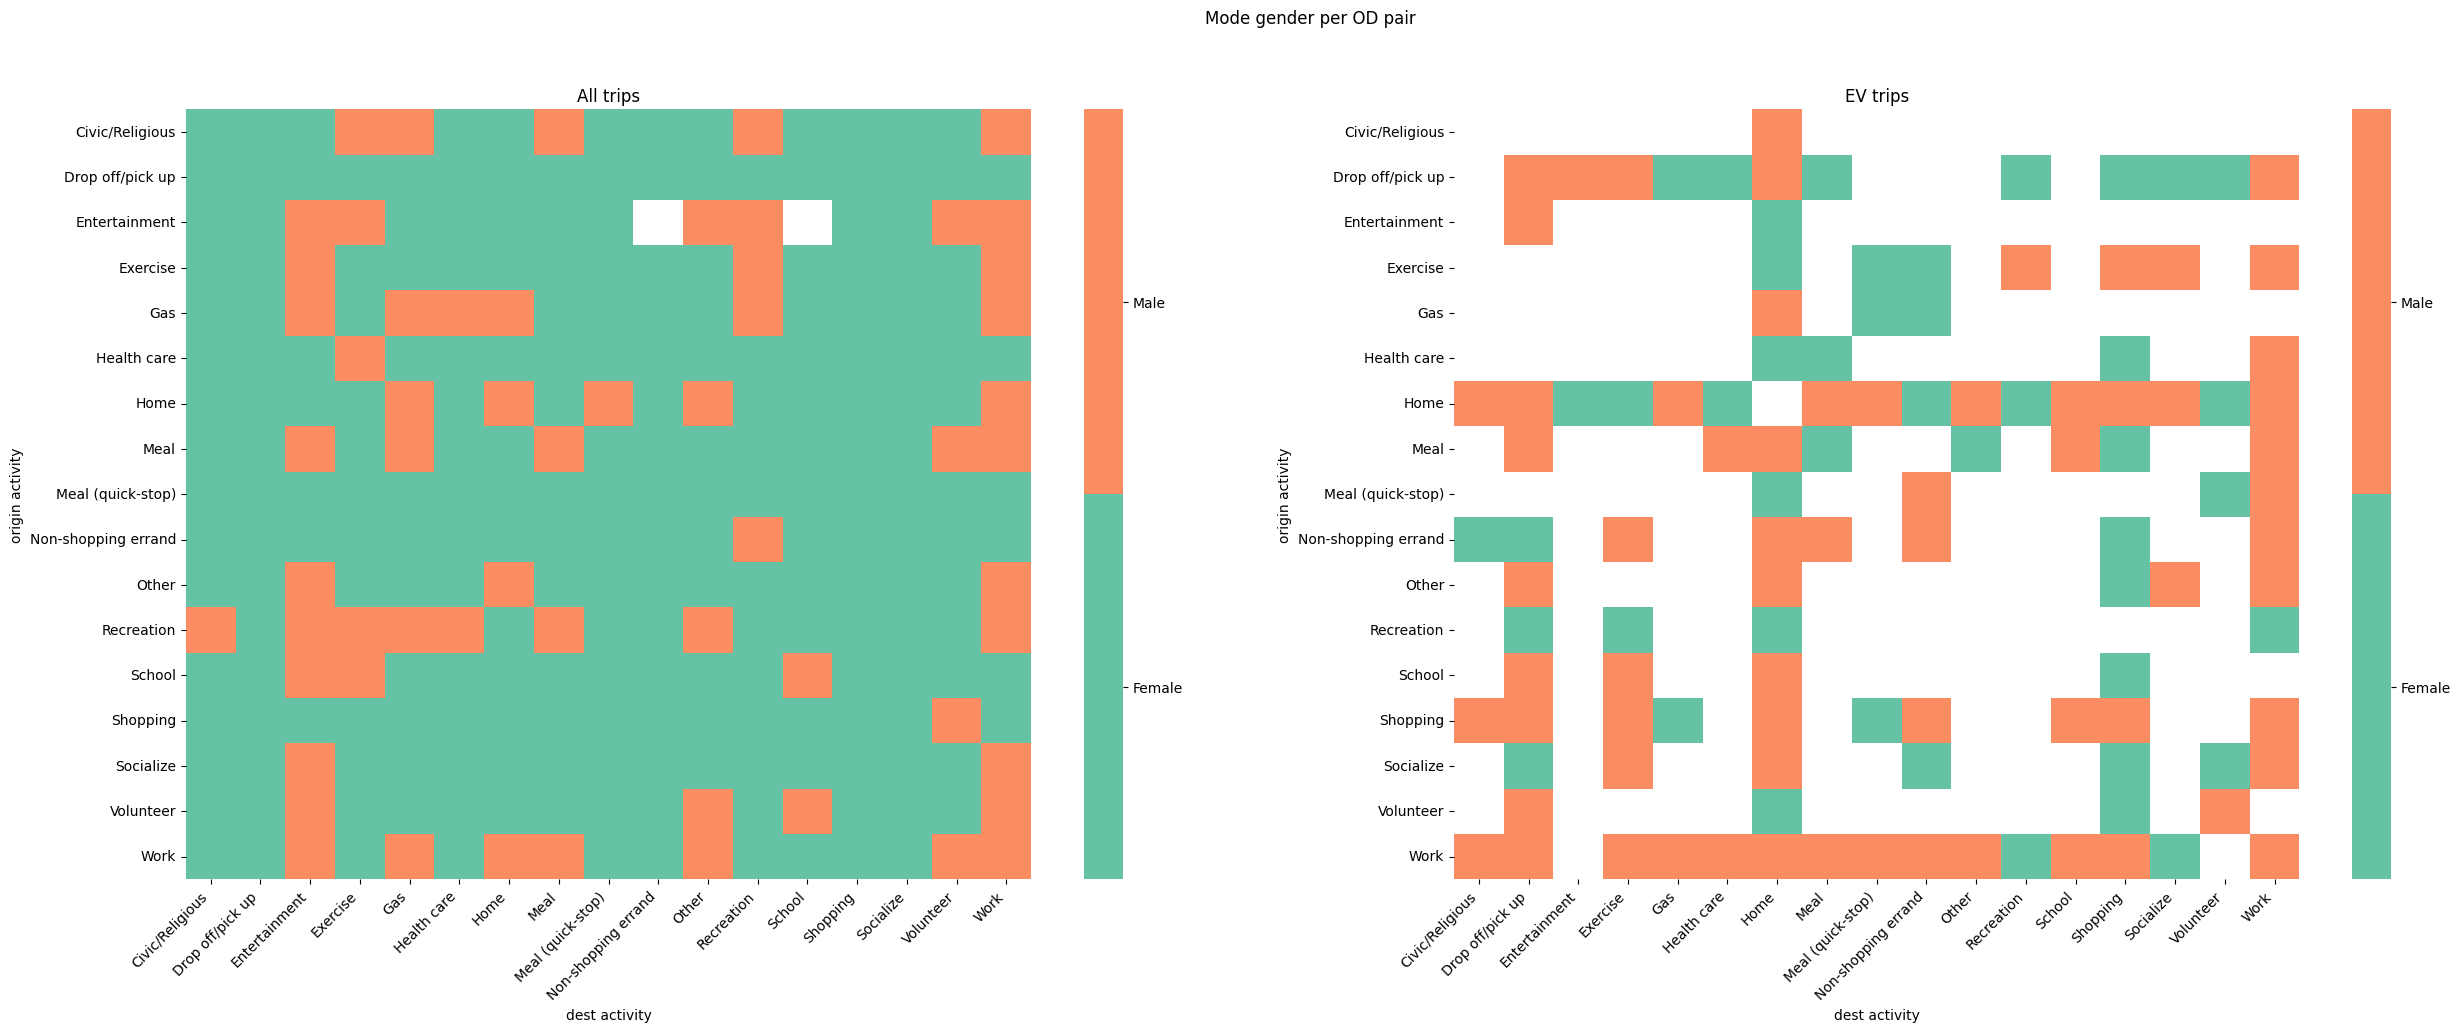

In [11]:
mode_od_heatmap(
    profiles,
    extractor = attrgetter("gender"),
    label_order = [label for label in GENDER_LABELS.values() if label is not None],
    mode_priority = ["Female", "Male"],
    title = "Mode gender per OD pair",
)

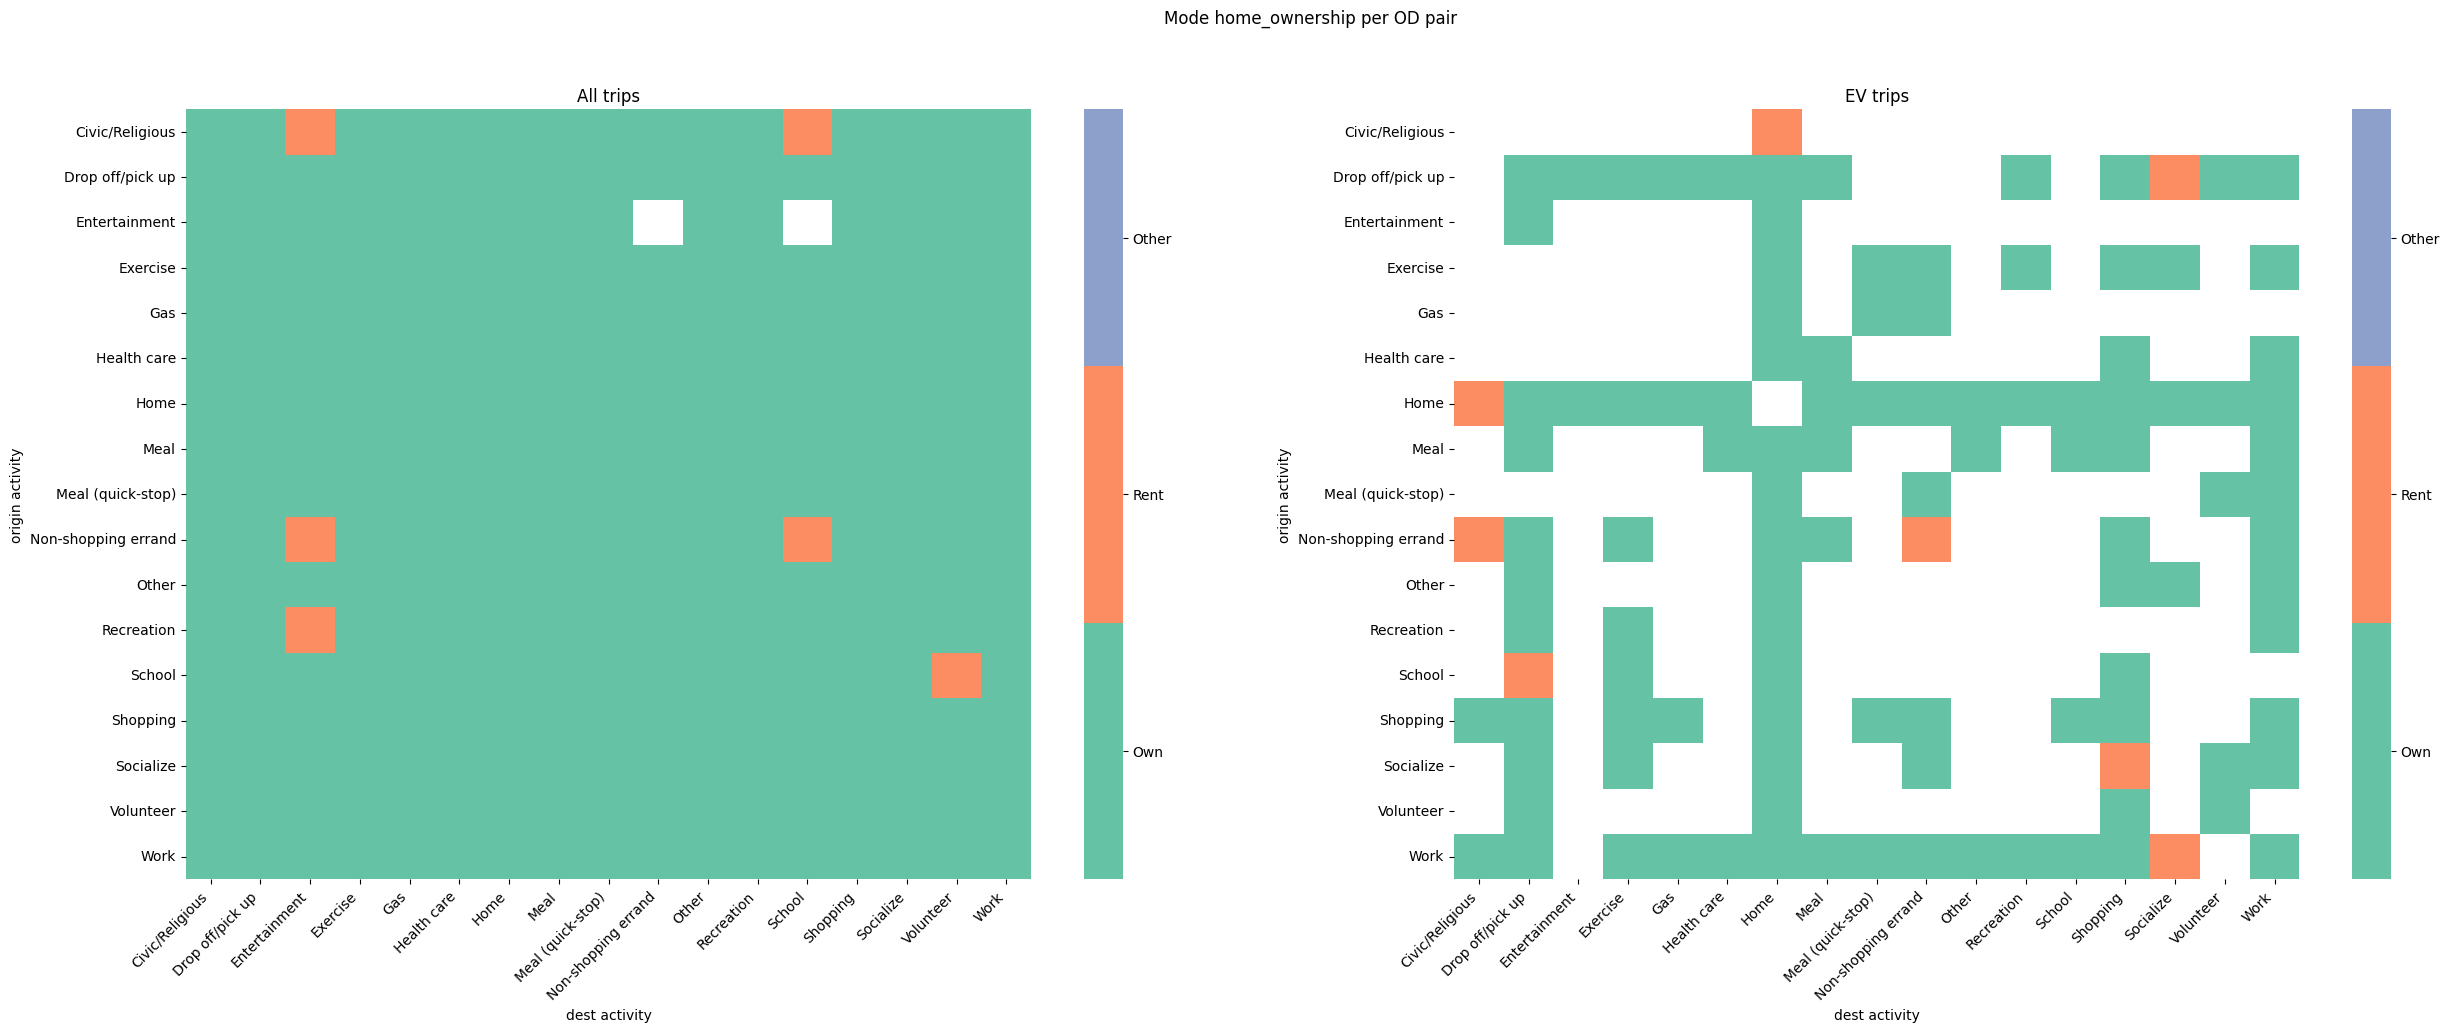

In [12]:
mode_od_heatmap(
    profiles,
    extractor = attrgetter("home_ownership"),
    label_order = [label for label in HOME_OWNERSHIP_LABELS.values() if label is not None],
    mode_priority = ["Other", "Rent", "Own"],
    title = "Mode home_ownership per OD pair",
)

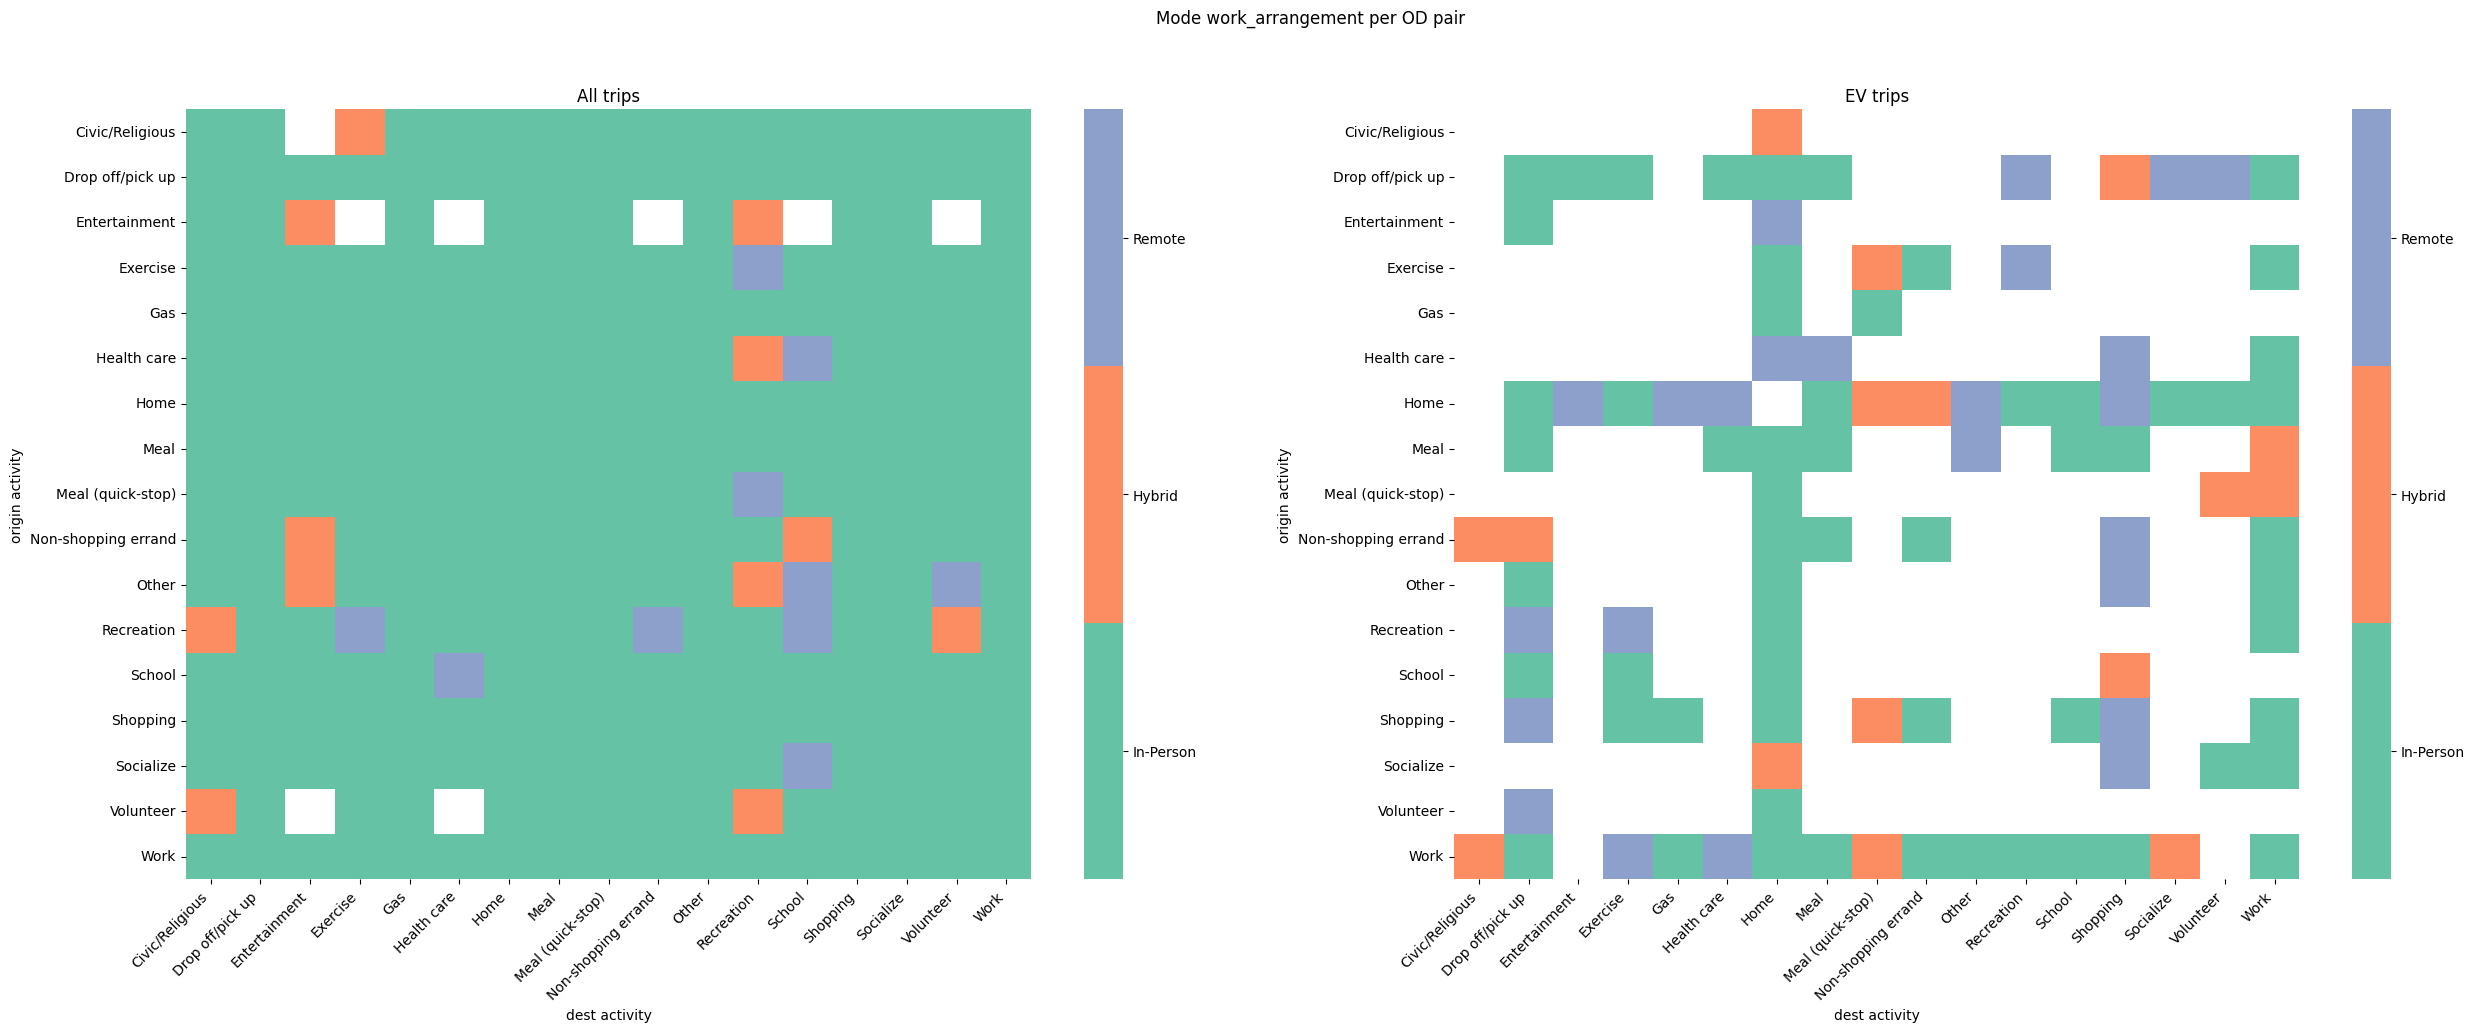

In [13]:
def extract_work_arrangement(profile: Profile) -> str | None:
    arrangement = profile.attributes.work_arrangement
    return arrangement.value if arrangement is not None else None

mode_od_heatmap(
    profiles,
    extractor = extract_work_arrangement,
    label_order = [member.value for member in WorkArrangement],
    mode_priority = ["Remote", "Hybrid", "In-Person"],
    title = "Mode work_arrangement per OD pair",
)

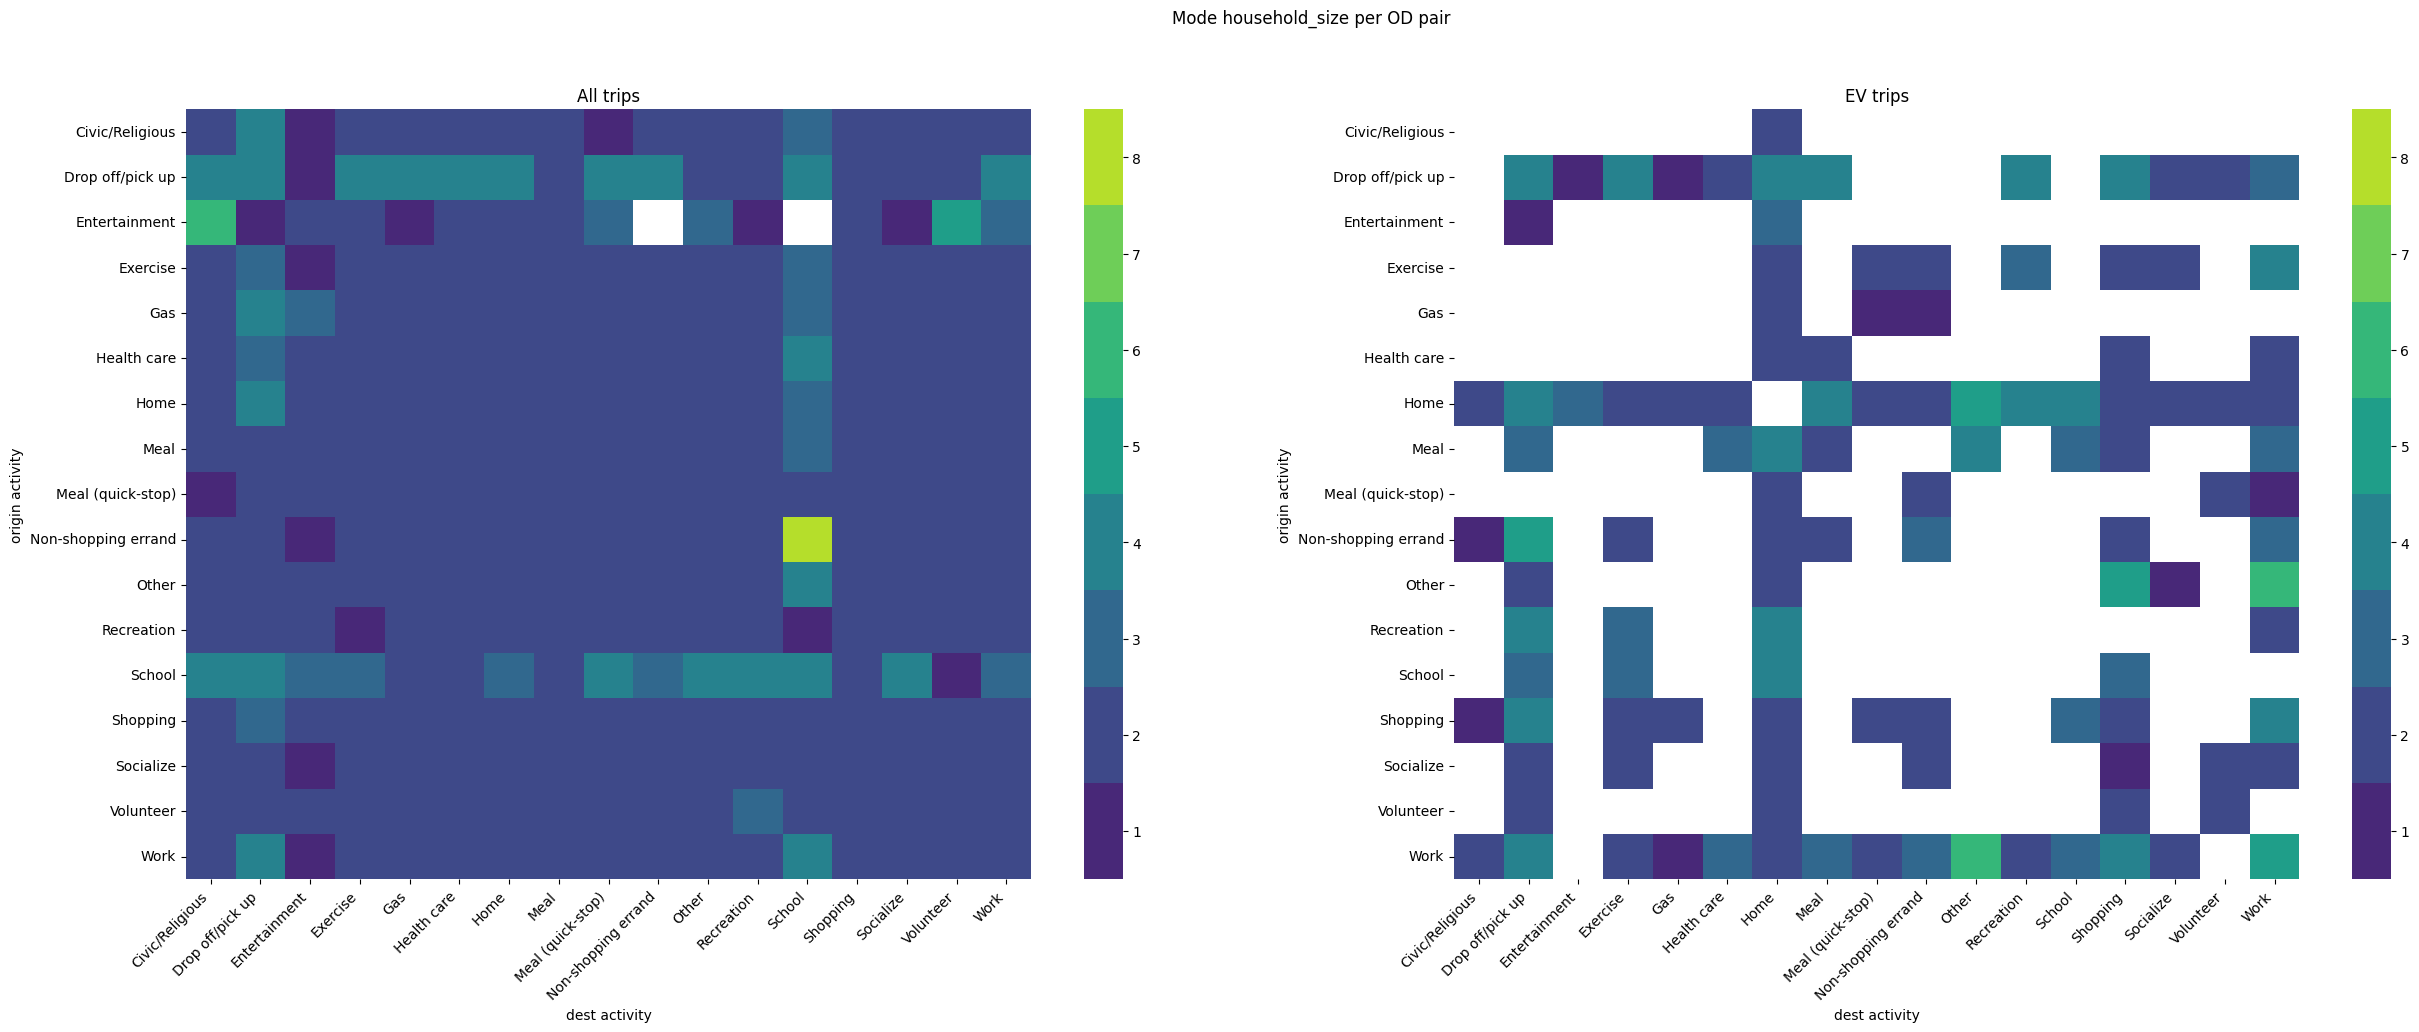

In [14]:
household_sizes: list[int] = sorted({profile.household_size for profile in profiles})

mode_od_heatmap(
    profiles,
    extractor = lambda profile: str(profile.household_size),
    label_order = [str(size) for size in household_sizes],
    mode_priority = [str(size) for size in reversed(household_sizes)],
    title = "Mode household_size per OD pair",
    palette = "viridis",
)

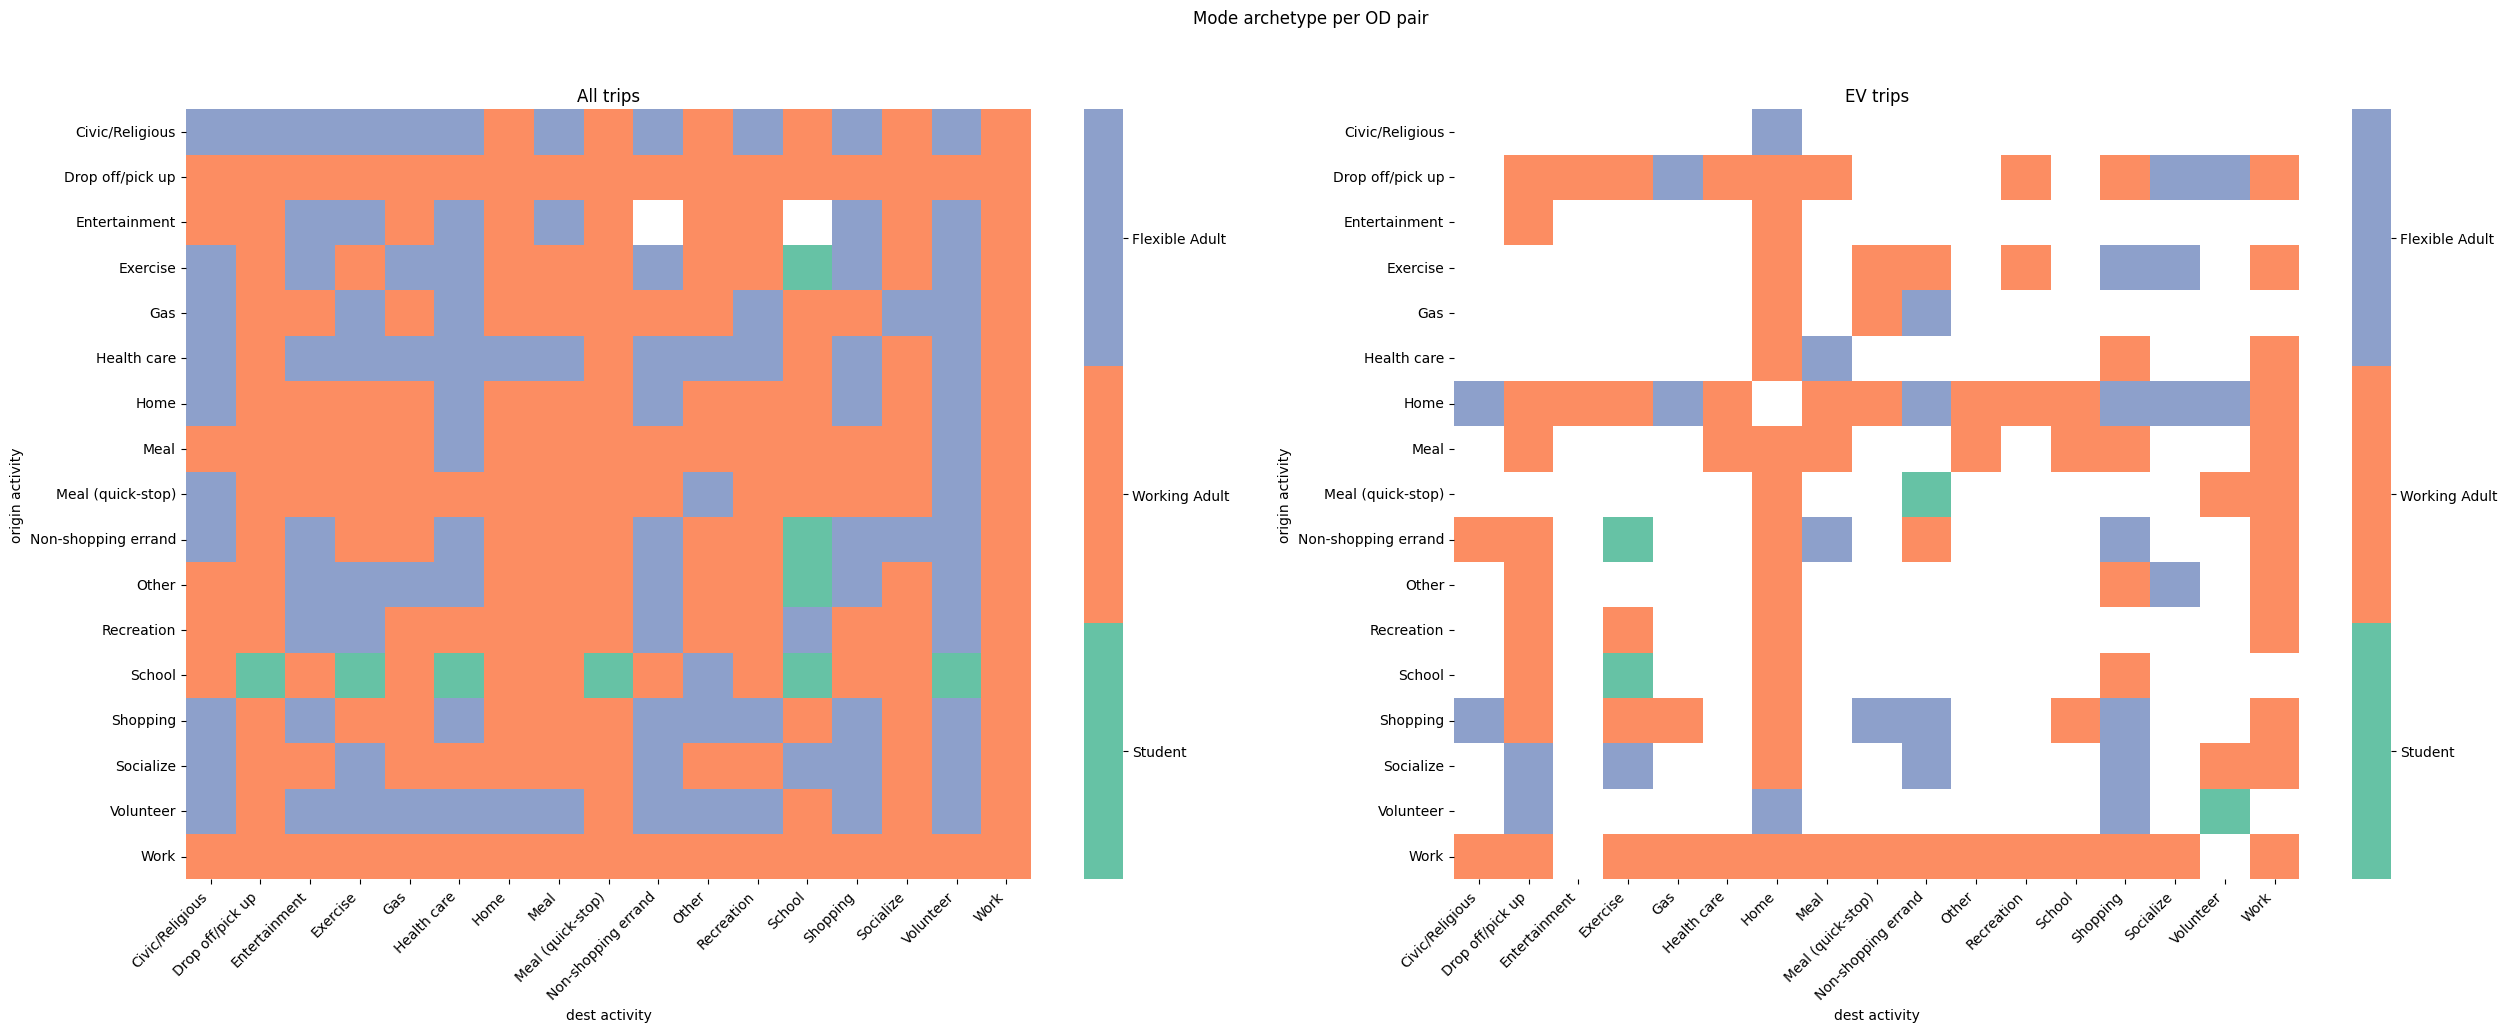

In [15]:
mode_od_heatmap(
    profiles,
    extractor = lambda profile: profile.archetype.value,
    label_order = [member.value for member in Archetype],
    mode_priority = ["Student", "Flexible Adult", "Working Adult"],
    title = "Mode archetype per OD pair",
)